# Stiffness & Rotation-Frame Analysis

Interprets the **impedance stiffness** and **rotation-frame** metrics logged by
`runs/glued_rot_rew`, split by task **phase** (`free_space` -> `search` ->
`insertion`). The metrics are gauge-invariant descriptors of the translational
stiffness `K` measured relative to the peg/insertion axis (see
`wrappers/controllers/ctrl_action_interface.py`):

* **k_axial** (k$_\parallel$) -- stiffness along insertion
* **k_lateral** (k$_\perp$) -- mean in-plane stiffness
* **anisotropy_ratio** ($\rho$=k$_\parallel$/k$_\perp$) -- <1 = compliant-along / stiff-laterally
* **cross_coupling** -- sideways force from a unit axial push; 0 iff the peg axis is a principal axis of K
* **condition_number** -- conditioning of K
* **z_angle** -- deg between the policy's stiffness-frame z and the peg z (rotated modes only)

Loading lives in `data_loader.py`; plotting in `plot_tools.py`. This notebook
only sets parameters and renders outputs.

## 1. Imports

In [1]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# The utility modules (data_loader.py, plot_tools.py) live next to this notebook
# in data_analysis/. Make them importable whether the kernel starts in
# data_analysis/ or the repo root by walking up from the cwd to find them.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (os.path.join(d, "data_analysis"), d):
            if os.path.isfile(os.path.join(cand, "data_loader.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import data_loader as dl   # data loading + reduction (single source of truth)
import plot_tools as pt    # plotting + styling (single source of truth)

## 2. Global parameters

Folder, phases, reduction, output folder, and the shared `STYLE` object.

In [ ]:
# Root folder that contains the experiment-group sub-folders (runs/{FOLDER_NAME}).
PROJECT_ROOT = dl.find_project_root()
RUNS_ROOT = dl.runs_root()
FOLDER_NAME = "glued_rot_rew"

# Confidence band: mean +/- CI_Z * SEM across runs. 1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per group (ranked by peak success); -1 keeps all.
TOP_N = 1
SUCCESS_METRIC = "Episode / Success rate"

# Shared x-axis for time-series plots. XLIM is (min, max) or None.
XLABEL = "Env Steps"
XLIM = (0, 9900)

# Task phases the per-phase metrics are split into (block_agent._PHASE_NAMES):
#   free_space -> not engaged, no contact
#   search     -> in contact, not engaged
#   insertion  -> engaged
PHASES = ["free_space", "search", "insertion"]

# How each per-phase scalar is reduced per run before aggregating across runs.
# "mean_tail" averages the last few logged points (denoises the converged value);
# alternatives: "last", "at_best" (value at the run's peak-success step), "max".
REDUCE = "mean_tail"

# Dated output folder: runs/{FOLDER_NAME}/plots_{date}/{name}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_stiffrot_{datetime.now().strftime('%Y%m%d')}")

# Styling/context. Display names + colors default to the glued_rot_rew controller
# ladder (Fixed / VICES / Cholesky / GAS fixed-rot / GAS); see plot_tools.
STYLE = pt.PlotStyle(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)
STEP_CEILING = STYLE.step_ceiling

## 3. Load data

In [3]:
DATA = dl.load_data(FOLDER_NAME, RUNS_ROOT)
DATA = dl.filter_top_n(DATA, TOP_N, SUCCESS_METRIC, STEP_CEILING)

# Quick look at the per-phase metric families that exist in the loaded runs.
_fam = sorted({t.split("/")[0] for run in next(iter(DATA.values())) for t in run})
print("metric families:", [f for f in _fam if "Rotation" in f or "Impedance" in f])

I0000 00:00:1781643870.817642   72389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781643870.845062   72389 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781643871.497734   72389 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1_fixed: 3 runs loaded
2_VICES: 3 runs loaded
3_choleskey: 3 runs loaded
4_GAS_fixed_rot: 3 runs loaded
5_GAS: 3 runs loaded
metric families: ['RotationFrame_free_space', 'RotationFrame_insertion', 'RotationFrame_search']


## 4. Per-phase descriptor table

Numeric summary across runs (text, not LaTeX) for a chosen phase.

In [4]:
# End-of-training per-phase summary table (insertion phase shown). For each
# controller, the gauge-invariant stiffness descriptors measured relative to the
# peg axis (see ctrl_action_interface._log_stiffness_frame_metrics). Reduced with
# REDUCE, mean +/- 95% CI across runs; best per column NOT bolded (these are
# descriptive, not better/worse). Switch PHASE to compare phases.
PHASE = "insertion"
SR_TABLE_METRICS = [
    {"tag": f"RotationFrame_{PHASE}/k_axial_mean",          "header": "k$_\\parallel$",       "higher_is_better": True, "unit": "",  "scale": 1, "decimals": 1},
    {"tag": f"RotationFrame_{PHASE}/k_lateral_mean",        "header": "k$_\\perp$",           "higher_is_better": True, "unit": "",  "scale": 1, "decimals": 1},
    {"tag": f"RotationFrame_{PHASE}/anisotropy_ratio_mean", "header": "$\\rho$",              "higher_is_better": True, "unit": "",  "scale": 1, "decimals": 2},
    {"tag": f"RotationFrame_{PHASE}/cross_coupling_mean",   "header": "cross-coupling",     "higher_is_better": True, "unit": "N", "scale": 1, "decimals": 1},
    {"tag": f"RotationFrame_{PHASE}/condition_number_mean", "header": "cond($K$)",          "higher_is_better": True, "unit": "",  "scale": 1, "decimals": 2},
]

# summarize_tag reduces per run then aggregates -> {group: (mean, ci, vals)}.
print(f"Per-phase stiffness descriptors ({PHASE}, reduce={REDUCE})\n")
hdr = ["controller"] + [m["header"].replace("$", "").replace("\\", "") for m in SR_TABLE_METRICS]
print("  ".join(f"{h:>14}" for h in hdr))
for group in DATA:
    cells = [STYLE.name(group)]
    for m in SR_TABLE_METRICS:
        s = dl.summarize_tag(DATA, m["tag"], reduce=REDUCE, ci_z=CI_Z, step_ceiling=STEP_CEILING)
        cells.append(f"{s[group][0]:.2f}" if group in s else "--")
    print("  ".join(f"{c:>14}" for c in cells))

Per-phase stiffness descriptors (insertion, reduce=mean_tail)

    controller      k_parallel          k_perp             rho  cross-coupling         cond(K)
         Fixed          565.00          565.00            1.00            0.00            1.00
         VICES          512.90          588.31            0.89           19.12            1.50
      Cholesky          466.77          486.88            0.98          263.47            6.89
GAS (fixed rot)          563.06          534.81            1.09            9.57            1.61
           GAS          459.52          473.34            0.98           44.76            1.35


## 5. Phase-trajectory small-multiples

The main diagnostic: how each controller adapts each descriptor across phases.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/phase_trajectories.svg


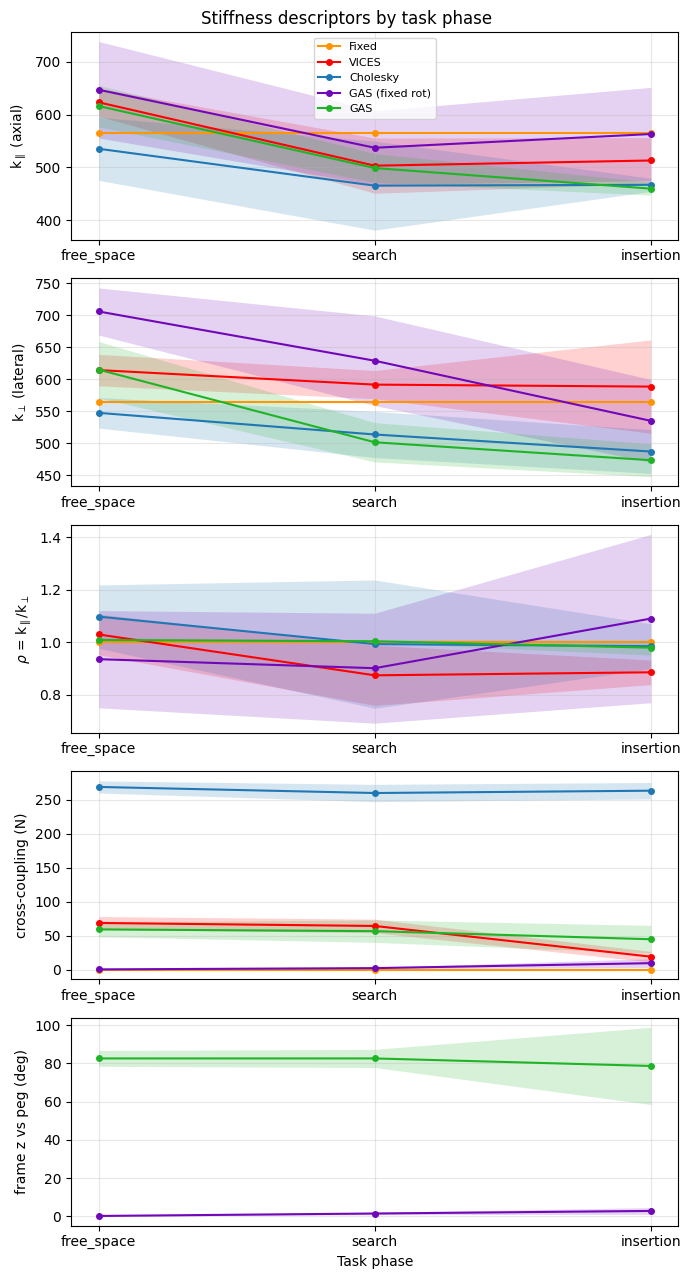

In [5]:
# (1) Phase-trajectory small-multiples -- the diagnostic workhorse.
# One row per gauge-invariant descriptor; x = task phase (free -> search ->
# insertion); one mean+CI line per controller. Reads off HOW each controller
# adapts its stiffness as it transitions from free motion to engaged insertion.
SPECS = [
    {"tag_template": "RotationFrame_{phase}/k_axial_mean",          "label": "k$_\\parallel$ (axial)"},
    {"tag_template": "RotationFrame_{phase}/k_lateral_mean",        "label": "k$_\\perp$ (lateral)"},
    {"tag_template": "RotationFrame_{phase}/anisotropy_ratio_mean", "label": "$\\rho$ = k$_\\parallel$/k$_\\perp$"},
    {"tag_template": "RotationFrame_{phase}/cross_coupling_mean",   "label": "cross-coupling (N)"},
    {"tag_template": "RotationFrame_{phase}/z_angle",               "label": "frame z vs peg (deg)"},
]

fig = pt.plot_phase_trajectories(DATA, SPECS, PHASES, STYLE, reduce=REDUCE,
                                 suptitle="Stiffness descriptors by task phase")
pt.save_plot(fig, "phase_trajectories", STYLE)
plt.show()

## 6. k$_\parallel$ vs k$_\perp$ scatter (phase paths)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/axial_vs_lateral.svg


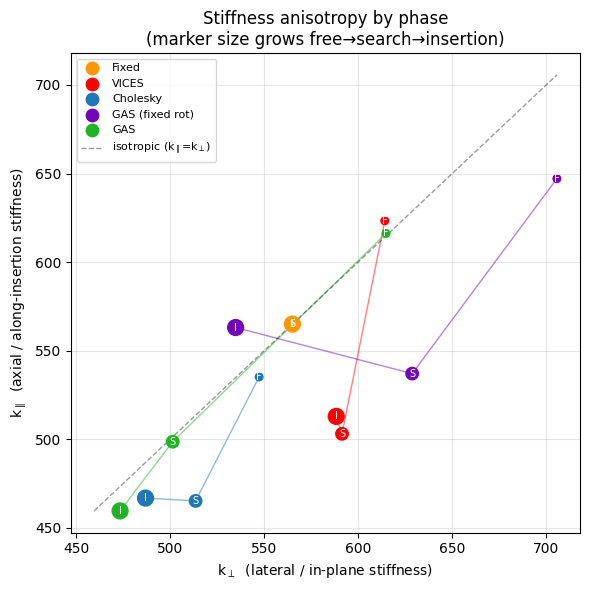

In [6]:
# (2) k_axial vs k_lateral scatter, with a phase path per controller.
# Marker size grows free -> search -> insertion. Below the dashed y=x line =
# compliant-along-the-peg / stiff-laterally (the usual insertion strategy).
ax = pt.plot_axial_lateral_scatter(DATA, PHASES, STYLE, reduce=REDUCE)
ax.figure.tight_layout()
pt.save_plot(ax.figure, "axial_vs_lateral", STYLE)
plt.show()

## 7. Stiffness-ellipse cartoon vs. peg axis

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/stiffness_ellipses.svg


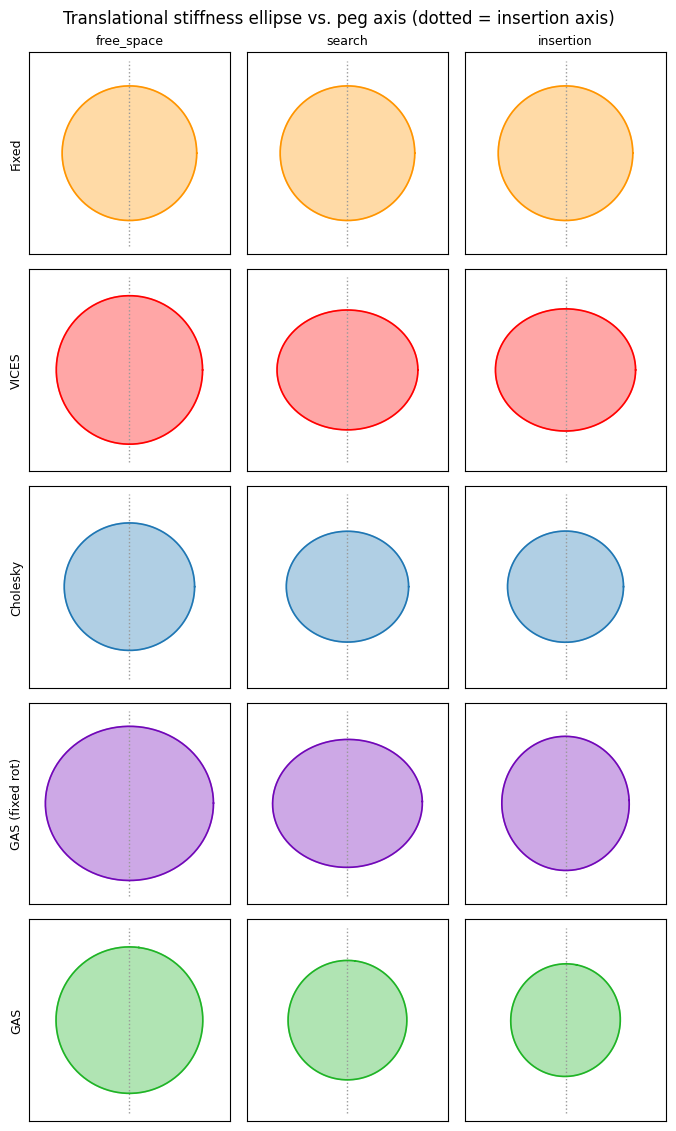

In [7]:
# (3) Stiffness-ellipse cartoon vs. the peg axis. Rows = controller, cols = phase.
# Peg/insertion axis is the dotted vertical line; the ellipse uses k_axial,
# k_lateral and is tilted by z_angle. Round = isotropic, squished-along-peg =
# compliant insertion, tilted = off-axis expressiveness (what GAS adds).
fig = pt.plot_stiffness_ellipses(DATA, PHASES, STYLE, reduce=REDUCE)
pt.save_plot(fig, "stiffness_ellipses", STYLE)
plt.show()

## 8. Training-time curves, faceted by phase

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/training_cross_coupling_mean_by_phase.svg


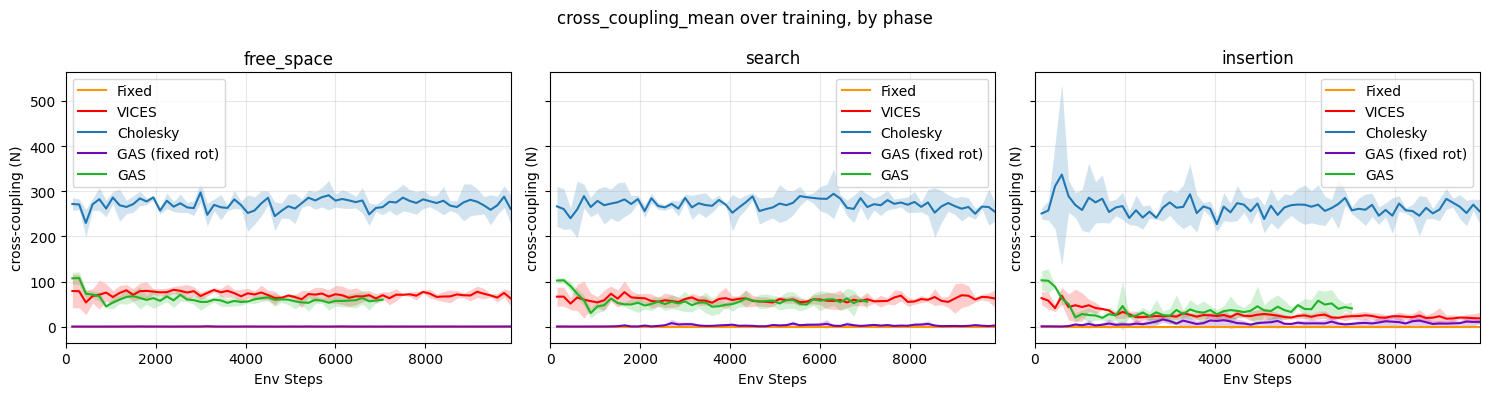

In [8]:
# (4) Training-time curves for one descriptor, faceted by phase. Answers "did the
# policy LEARN to use this, in which phase, and when in training?". Change METRIC
# to any RotationFrame_{phase}/... or Impedance_Stiffness_{phase}/pos_... tag.
METRIC = "cross_coupling_mean"
YLABEL = "cross-coupling (N)"

fig, axes = plt.subplots(1, len(PHASES), figsize=(5 * len(PHASES), 4), sharey=True)
for ax, phase in zip(axes, PHASES):
    pt.plot_metric(DATA, f"RotationFrame_{phase}/{METRIC}", YLABEL,
                   f"{phase} ()", STYLE, ax=ax, legend_loc="best")
    ax.set_title(phase)
fig.suptitle(f"{METRIC} over training, by phase")
fig.tight_layout()
pt.save_plot(fig, f"training_{METRIC}_by_phase", STYLE)
plt.show()

## 9. Controller x phase heatmap

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/heatmap_anisotropy.svg


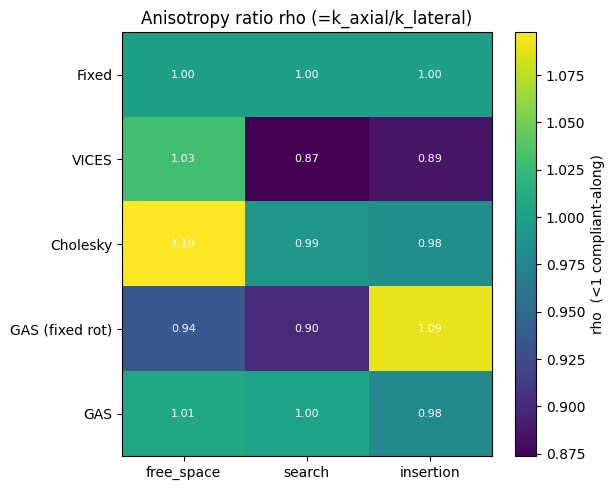

In [9]:
# (5) Controller x phase heatmap of a single descriptor -- the at-a-glance summary.
HEAT_TAG = "RotationFrame_{phase}/anisotropy_ratio_mean"
HEAT_TITLE = "Anisotropy ratio rho (=k_axial/k_lateral)"
HEAT_CBAR = "rho  (<1 compliant-along)"

ax = pt.plot_phase_heatmap(DATA, HEAT_TAG, PHASES, STYLE, reduce=REDUCE,
                           title=HEAT_TITLE, cbar_label=HEAT_CBAR, fmt="{:.2f}")
ax.figure.tight_layout()
pt.save_plot(ax.figure, "heatmap_anisotropy", STYLE)
plt.show()

## 10. Stiffness expressiveness vs. success

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/crosscoupling_vs_success.svg


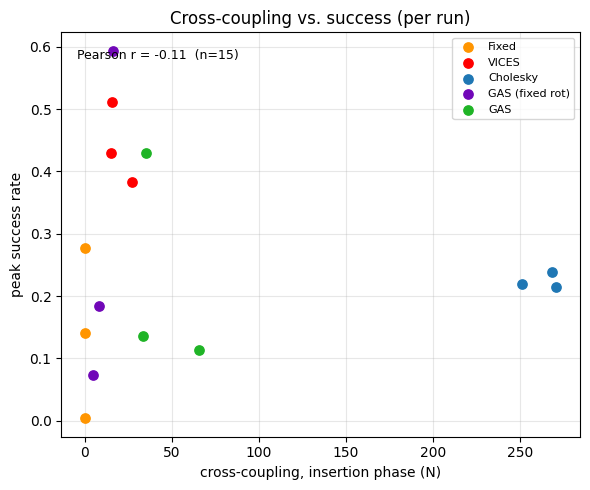

In [10]:
# (6) Does stiffness expressiveness correlate with success? One point per run.
# Tests whether more off-axis coupling / anisotropy actually buys insertions.
METRIC_TAG = "RotationFrame_insertion/cross_coupling_mean"
ax = pt.plot_metric_vs_success(
    DATA, METRIC_TAG, "Episode / Success rate", STYLE,
    metric_reduce=REDUCE, success_reduce="max",
    xlabel="cross-coupling, insertion phase (N)", ylabel="peak success rate",
    title="Cross-coupling vs. success (per run)")
ax.figure.tight_layout()
pt.save_plot(ax.figure, "crosscoupling_vs_success", STYLE)
plt.show()

## 11. Bonus: applied stiffness in the controller frame

Contrast with the peg-frame descriptors above to see why the rotation matters.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/glued_rot_rew/plots_stiffrot_20260616/controller_frame_stiffness.svg


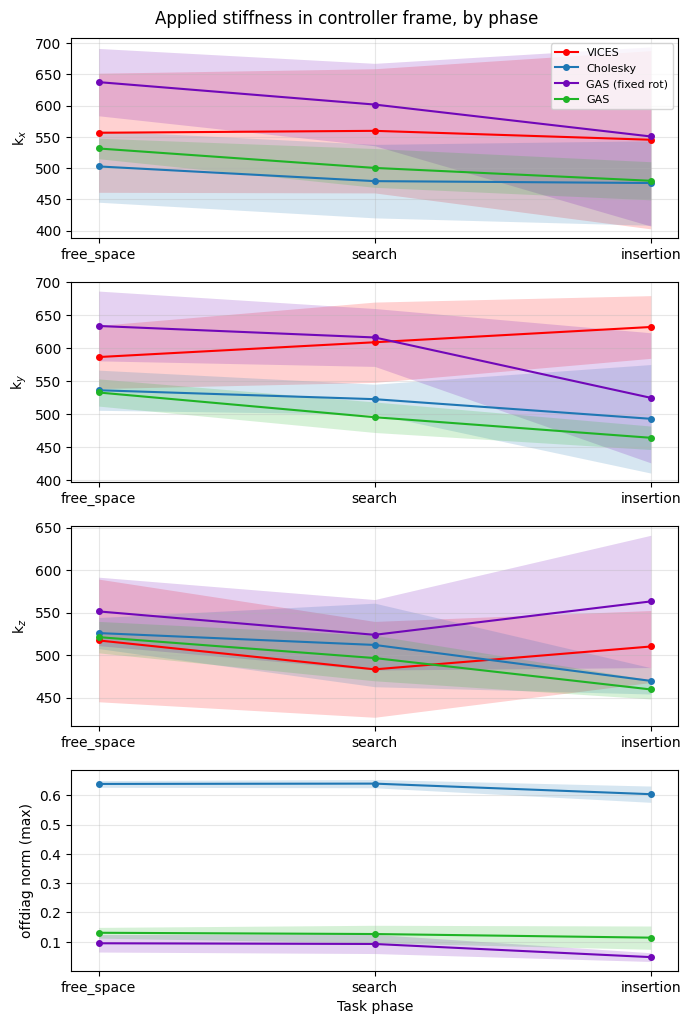

In [11]:
# (Bonus) Raw applied stiffness in the CONTROLLER's own frame, per phase. Unlike
# the RotationFrame_* metrics (measured vs the peg axis in world frame), these are
# the diagonal gains as parameterized. Contrast offdiag_norm here (~0 for a frame
# that is diagonal in its own basis) with cross-coupling above (nonzero when that
# frame is tilted off the peg) -- the same K, two frames, why rotation matters.
SPECS = [
    {"tag_template": "Impedance_Stiffness_{phase}/pos_X",               "label": "k$_x$"},
    {"tag_template": "Impedance_Stiffness_{phase}/pos_Y",               "label": "k$_y$"},
    {"tag_template": "Impedance_Stiffness_{phase}/pos_Z",               "label": "k$_z$"},
    {"tag_template": "Impedance_Stiffness_{phase}/pos_offdiag_norm_max", "label": "offdiag norm (max)"},
]
fig = pt.plot_phase_trajectories(DATA, SPECS, PHASES, STYLE, reduce=REDUCE,
                                 suptitle="Applied stiffness in controller frame, by phase")
pt.save_plot(fig, "controller_frame_stiffness", STYLE)
plt.show()